## Section 1 — Install Dependencies

In [1]:
!pip install -q \
transformers==4.40.0 \
accelerate==0.29.0 \
peft==0.10.0 \
sympy==1.12 \
datasets evaluate rouge_score bert_score \
sacrebleu nltk sentencepiece \
plotly gradio scikit-learn

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print('Dependencies installed ✓')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.3/297.3 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.2 MB/s eta 0:00:00
   ━━━━━

## Section 2 — Imports & Constants

In [2]:
import os, re, json, shutil, warnings, random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, set_seed,
    EarlyStoppingCallback,
)
from peft import get_peft_model, LoraConfig, TaskType
import evaluate

import matplotlib.pyplot as plt
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
set_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

OUTPUT_DIR    = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
VIT5_OUT_DIR  = str(OUTPUT_DIR / 'vit5_finetuned')
VIT5_PREFIX   = 'tóm tắt: '

print('Imports done ✓')

Device : cuda
GPU    : Tesla T4
Imports done ✓


## Section 3 — Data Loading, Augmentation & Split

### Data Augmentation Strategy
To enlarge the training set without violating the number-preservation constraint we apply **two lightweight, number-safe techniques on the article only** (summary is never modified):

| Method | What it does | Why it's safe |
|---|---|---|
| **Synonym Swap** | Replaces common Vietnamese sports words with synonyms from a curated dict | Only non-numeric tokens are swapped |
| **Sentence Shuffle** | Randomly reorders sentences in the article | Numbers stay; model can't rely on position |

> Val and Test sets are **never augmented** to keep evaluation clean.

In [3]:
## Section 3 — Data Loading

print("Loading prepared dataset...")

train_df_aug = pd.read_csv("train.csv")
val_df       = pd.read_csv("val.csv")

print(f"Train size : {len(train_df_aug)}")
print(f"Val size   : {len(val_df)}")

Loading prepared dataset...
Train size : 2553
Val size   : 106


## Section 4 — Dataset & Tokenization Utilities

In [4]:
class SummarizationDataset(Dataset):
    def __init__(self, df, tokenizer, max_input=1024, max_target=256, prefix=''):
        self.df         = df.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_input  = max_input
        self.max_target = max_target
        self.prefix     = prefix

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        article = self.prefix + str(self.df.loc[idx, 'article'])
        summary = str(self.df.loc[idx, 'summary'])

        model_inputs = self.tokenizer(
            article,
            max_length=self.max_input,
            truncation=True,
            padding=False,
        )

        labels = self.tokenizer(
            text_target=summary,
            max_length=self.max_target,
            truncation=True,
            padding=False,
        )

        model_inputs['labels'] = labels['input_ids']
        return model_inputs


def compute_metrics_factory(tokenizer):
    rouge = evaluate.load('rouge')
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
        labels      = np.where(labels      != -100, labels,      tokenizer.pad_token_id)
        preds = [p.strip() for p in tokenizer.batch_decode(predictions, skip_special_tokens=True)]
        refs  = [l.strip() for l in tokenizer.batch_decode(labels,      skip_special_tokens=True)]
        r = rouge.compute(predictions=preds, references=refs, use_stemmer=False)
        return {'rouge1': round(r['rouge1'],4), 'rouge2': round(r['rouge2'],4), 'rougeL': round(r['rougeL'],4)}
    return compute_metrics

print('Dataset utilities ready ✓')

Dataset utilities ready ✓


## Section 6 — Model 2: ViT5-base Fine-tuning

**Architecture:** T5-base pretrained on 40 GB Vietnamese text (span-corruption objective).  
**Why chosen:** Larger pretraining corpus; text-to-text format fits summarisation with task prefix.  
**Task prefix:** `"tóm tắt: "` prepended to every input.  
**LoRA config:** `r=16, alpha=32`, targets `q` & `v` (T5 layer names differ from BART).

No checkpoint found — training from scratch...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/820k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Parameters: 225,950,976
trainable params: 1,769,472 || all params: 227,720,448 || trainable%: 0.7770369396076369


Starting ViT5 fine-tuning…


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
0,2.598500,2.235852,0.375300,0.103700,0.241500
1,2.166500,1.962652,0.459200,0.155600,0.279800
2,2.034700,1.883082,0.485700,0.173800,0.284600
4,1.845100,1.807976,0.564400,0.231500,0.313500
5,1.764700,1.793876,0.554100,0.232400,0.307300
6,1.710000,1.797367,0.592700,0.245100,0.323000
8,1.615900,1.785131,0.613000,0.266700,0.331800
9,1.576300,1.793190,0.592900,0.250700,0.321600
10,1.553700,1.796436,0.607000,0.261000,0.327900
12,1.522000,1.790884,0.616100,0.272600,0.330600


ViT5 saved → outputs/vit5_finetuned ✓
Running final evaluation...


Final metrics saved ✓


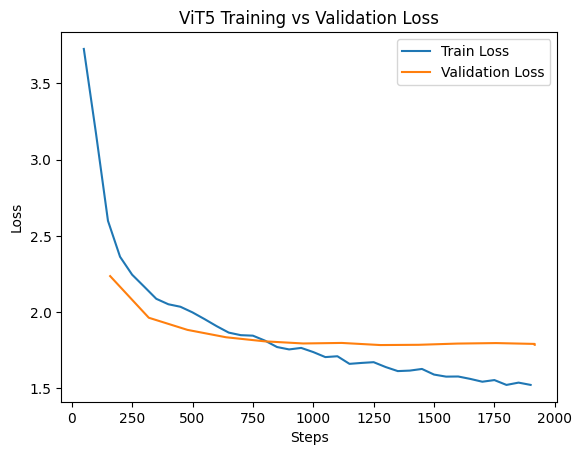

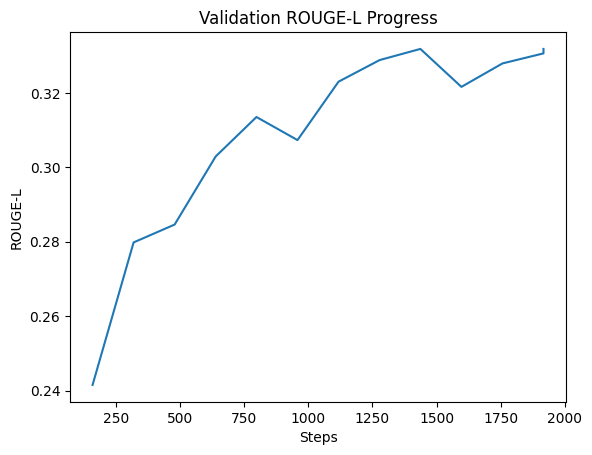

In [5]:
VIT5_MODEL = 'VietAI/vit5-base'

if Path(VIT5_OUT_DIR).exists() and any(Path(VIT5_OUT_DIR).iterdir()):
    print("ViT5 checkpoint found — skipping training, loading directly.")
    vit5_tokenizer = AutoTokenizer.from_pretrained(VIT5_OUT_DIR)
    vit5_model     = AutoModelForSeq2SeqLM.from_pretrained(VIT5_OUT_DIR).to(DEVICE)
    print("ViT5 loaded ✓")
else:
    print("No checkpoint found — training from scratch...")
    vit5_tokenizer = AutoTokenizer.from_pretrained(VIT5_MODEL)
    vit5_base      = AutoModelForSeq2SeqLM.from_pretrained(VIT5_MODEL)
    print(f"Parameters: {sum(p.numel() for p in vit5_base.parameters()):,}")

    lora_cfg_v5 = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM, r=16, lora_alpha=32,
        target_modules=['q', 'v'], lora_dropout=0.1, bias='none',
    )
    vit5_model = get_peft_model(vit5_base, lora_cfg_v5)
    vit5_model.print_trainable_parameters()

    vit5_train = SummarizationDataset(train_df_aug, vit5_tokenizer, prefix=VIT5_PREFIX)
    vit5_val   = SummarizationDataset(val_df,       vit5_tokenizer, prefix=VIT5_PREFIX)
    collator_v5 = DataCollatorForSeq2Seq(vit5_tokenizer, model=vit5_model, padding=True, pad_to_multiple_of=8)

    args_v5 = Seq2SeqTrainingArguments(
        output_dir=VIT5_OUT_DIR,
        num_train_epochs=20,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        warmup_ratio=0.15,
        weight_decay=0.01,
        lr_scheduler_type='cosine',
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='rougeL',
        greater_is_better=True,
        predict_with_generate=True,
        generation_max_length=256,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        report_to='none',
        save_total_limit=2,
    )

    trainer_v5 = Seq2SeqTrainer(
        model=vit5_model,
        args=args_v5,
        train_dataset=vit5_train,
        eval_dataset=vit5_val,
        tokenizer=vit5_tokenizer,
        data_collator=collator_v5,
        compute_metrics=compute_metrics_factory(vit5_tokenizer),
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=3,
                early_stopping_threshold=0.001
            )
        ],
    )

    print("Starting ViT5 fine-tuning…")
    trainer_v5.train()
    trainer_v5.save_model(VIT5_OUT_DIR)
    vit5_tokenizer.save_pretrained(VIT5_OUT_DIR)
    print(f"ViT5 saved → {VIT5_OUT_DIR} ✓")

    print("Running final evaluation...")
    metrics = trainer_v5.evaluate()
    with open(f"{VIT5_OUT_DIR}/final_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)
    print("Final metrics saved ✓")

    # ===== Training history visualization =====
    log_history = trainer_v5.state.log_history
    history_df  = pd.DataFrame(log_history)
    history_df.to_csv(f"{VIT5_OUT_DIR}/training_log.csv", index=False)

    train_logs = history_df[history_df['loss'].notna()]
    eval_logs  = history_df[history_df['eval_loss'].notna()]

    plt.figure()
    plt.plot(train_logs['step'], train_logs['loss'], label='Train Loss')
    plt.plot(eval_logs['step'],  eval_logs['eval_loss'], label='Validation Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('ViT5 Training vs Validation Loss')
    plt.legend()
    plt.show()

    if 'eval_rougeL' in eval_logs.columns:
        plt.figure()
        plt.plot(eval_logs['step'], eval_logs['eval_rougeL'])
        plt.xlabel('Steps')
        plt.ylabel('ROUGE-L')
        plt.title('Validation ROUGE-L Progress')
        plt.show()



In [6]:
# ===== Quick Sanity Check =====
print("=== Sample Predictions ===")

sample_df = pd.read_csv('test.csv').head(2)

def count_words(text):
    return len(str(text).split())

def extract_numbers(text):
    import re
    pattern = re.compile(r'\b\d{4}-\d{4}\b|\b\d{1,2}/\d{1,2}/\d{2,4}\b|\b\d{1,2}/\d{1,2}\b|\b\d+(?:[.,]\d+)*%?\b|\b\d+\s*-\s*\d+\b|\b\d+[hH]\d{2}\b')
    return set(pattern.findall(str(text)))

for idx, row in sample_df.iterrows():
    article = str(row['article'])
    reference = str(row['summary'])

    inputs = vit5_tokenizer(article, return_tensors='pt', max_length=1024, truncation=True)
    inputs.pop('token_type_ids', None)
    inputs = inputs.to(DEVICE)

    aw = count_words(article)
    with torch.no_grad():
        out = vit5_model.generate(
            **inputs,
            num_beams=4,
            length_penalty=0.8,
            min_length=max(10, int(aw * 0.20)),
            max_length=min(512, int(aw * 0.25)),
            early_stopping=True,
            no_repeat_ngram_size=3,
        )
    pred = vit5_tokenizer.decode(out[0], skip_special_tokens=True)

    art_nums  = extract_numbers(article)
    pred_nums = extract_numbers(pred)
    missing   = art_nums - pred_nums
    ratio     = count_words(pred) / aw if aw > 0 else 0

    print(f'\n--- Sample {idx+1} ---')
    print(f'ARTICLE  : {article[:200]}...')
    print(f'REFERENCE: {reference}')
    print(f'PREDICTED: {pred}')
    print(f'Length ratio: {ratio:.2%} | Missing numbers: {missing or "none"}')

=== Sample Predictions ===

--- Sample 1 ---
ARTICLE  : Trước Trung Quốc đang xuống tinh thần sau ba trận toàn thua, HLV Shin Tae-yong vẫn thận trọng, cho Indonesia đá theo sơ đồ 5-4-1. Nhà cầm quân Hàn Quốc cũng dùng tới chín cầu thủ được nhập tịch vốn si...
REFERENCE: Trung Quốc giành chiến thắng đầu tiên tại vòng loại World Cup 2026 khi đánh bại Indonesia. Trước 10.000 khán giả nhà, họ chơi kiên cường dù đối thủ áp đảo với 75 phần trăm thời lượng kiểm soát bóng và thực hiện hơn 300 đường chuyền. Phút 21, Behram Abduweli mở tỷ số nhờ sai lầm hàng thủ khách. Phút 44, Zhang Yuning nhân đôi cách biệt sau đường kiến tạo của Gao Zhunyi, tình huống loại bỏ 5 cầu thủ đối phương. Indonesia sử dụng 9 cầu thủ nhập tịch và thay 4 vị trí sau giờ nghỉ nhưng bế tắc trước hệ thống phòng ngự 0 kẽ hở. Phút 87, số 19 Thom Haye ghi bàn rút ngắn cách biệt. Sau 2 hiệp đấu căng thẳng, Trung Quốc bảo vệ thành công tỷ số dù đối thủ dồn lên suốt 7 phút bù giờ. Trận đấu khép lại với kết quả 2-1 chung cuộc cho

In [7]:
!zip -r vit5.zip outputs/vit5_finetuned
from google.colab import files
files.download("vit5.zip")

  adding: outputs/vit5_finetuned/ (stored 0%)
  adding: outputs/vit5_finetuned/spiece.model (deflated 53%)
  adding: outputs/vit5_finetuned/training_args.bin (deflated 51%)
  adding: outputs/vit5_finetuned/training_log.csv (deflated 57%)
  adding: outputs/vit5_finetuned/final_metrics.json (deflated 42%)
  adding: outputs/vit5_finetuned/tokenizer.json (deflated 71%)
  adding: outputs/vit5_finetuned/adapter_model.safetensors (deflated 7%)
  adding: outputs/vit5_finetuned/checkpoint-1917/ (stored 0%)
  adding: outputs/vit5_finetuned/checkpoint-1917/spiece.model (deflated 53%)
  adding: outputs/vit5_finetuned/checkpoint-1917/rng_state.pth (deflated 25%)
  adding: outputs/vit5_finetuned/checkpoint-1917/training_args.bin (deflated 51%)
  adding: outputs/vit5_finetuned/checkpoint-1917/trainer_state.json (deflated 76%)
  adding: outputs/vit5_finetuned/checkpoint-1917/scheduler.pt (deflated 55%)
  adding: outputs/vit5_finetuned/checkpoint-1917/optimizer.pt (deflated 9%)
  adding: outputs/vit5_f

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>